# Phase 4.6: Hyperparameter Tuning

**Tujuan:** Mencari kombinasi hyperparameter terbaik untuk SVM (RBF), Random Forest, dan
XGBoost pada masing-masing dataset (GC, band PDC terbaik, Combined) menggunakan
GridSearchCV, lalu mengevaluasi ulang model dengan parameter terbaik via 5-fold CV agar
skor per-fold tetap sebanding dengan sub-phase 4.1-4.5 untuk uji signifikansi di 4.7.

**Output:** `output/tuning_best_params.csv`, `output/tuning_cv_scores.csv`, `output/tuning_results.csv`,
`output/svm_grid_full_results.csv`
**Figures:** `figures/svm_hyperparameter_heatmap.png`


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, cross_validate
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, r"D:\Skripsi\new_data")

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print("XGBoost is installed and will be tuned")
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed - skipping XGBoost tuning")

PHASE3_CSV_DIR = r"D:\Skripsi\new_data\phase_3_feature_engineering\csv"
OUTPUT_DIR = r"D:\Skripsi\new_data\phase_4_classification\4.6_hyperparameter_tuning\output"
FIG_DIR = r"D:\Skripsi\new_data\phase_4_classification\4.6_hyperparameter_tuning\figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)


XGBoost is installed and will be tuned


In [2]:
def _feature_cols(df):
    exclude = ['subject_id', 'subject_num', 'session', 'trial', 'class', 'class_label']
    exclude += [c for c in df.columns if 'hub_channel' in c]
    cols = [c for c in df.columns if c not in exclude and df[c].dtype in ['float64', 'int64']]
    return [c for c in cols if df[c].std() > 1e-10]

df_gc = pd.read_csv(os.path.join(PHASE3_CSV_DIR, "engineered_features_gc.csv"))
df_combined = pd.read_csv(os.path.join(PHASE3_CSV_DIR, "engineered_features_combined.csv"))
df_spectral = pd.read_csv(os.path.join(PHASE3_CSV_DIR, "engineered_features_spectral.csv"))

pdc_files = [f for f in os.listdir(PHASE3_CSV_DIR)
             if f.startswith("engineered_features_pdc_") and "broadband" not in f]

best_pdc, best_pdc_name, best_score = None, None, -1
print("Selecting best PDC band by mean ANOVA F-score:")
for f in pdc_files:
    df_pdc = pd.read_csv(os.path.join(PHASE3_CSV_DIR, f))
    band = f.replace("engineered_features_pdc_", "").replace(".csv", "")
    feat_cols = _feature_cols(df_pdc)
    f_scores, _ = f_classif(df_pdc[feat_cols].fillna(0).values, df_pdc['class'].values)
    score = np.nanmean(f_scores)
    print(f"  PDC {band.upper():5s}: mean F-score = {score:.4f} ({len(feat_cols)} features)")
    if score > best_score:
        best_score, best_pdc, best_pdc_name = score, df_pdc, f"PDC_{band.title()}"

print(f"\nGC shape       : {df_gc.shape}")
print(f"Best PDC band  : {best_pdc_name} (shape: {best_pdc.shape})")
print(f"Combined shape : {df_combined.shape}")
print(f"Spectral shape : {df_spectral.shape}")
ROI_DIR = r"D:\Skripsi\new_data\phase_3_feature_engineering\3.4_roi_aggregation\output"
df_gc_roi = pd.read_csv(os.path.join(ROI_DIR, "engineered_features_gc_roi.csv"))
df_pdc_roi = pd.read_csv(os.path.join(ROI_DIR, "engineered_features_pdc_roi_combined.csv"))
df_gc_pdc_roi = pd.read_csv(os.path.join(ROI_DIR, "engineered_features_roi_gc_pdc.csv"))
df_gc_pdc_roi_spectral = pd.read_csv(os.path.join(ROI_DIR, "engineered_features_roi_all.csv"))
print(f"GC_ROI shape             : {df_gc_roi.shape}")
print(f"PDC_ROI shape            : {df_pdc_roi.shape}")
print(f"GC+PDC_ROI shape         : {df_gc_pdc_roi.shape}")
print(f"GC+PDC_ROI+Spectral shape: {df_gc_pdc_roi_spectral.shape}")

Selecting best PDC band by mean ANOVA F-score:
  PDC ALPHA: mean F-score = 3.3176 (282 features)
  PDC BETA : mean F-score = 3.0740 (282 features)
  PDC DELTA: mean F-score = 3.2196 (282 features)
  PDC GAMMA: mean F-score = 2.9619 (282 features)
  PDC THETA: mean F-score = 3.4114 (282 features)

GC shape       : (675, 296)
Best PDC band  : PDC_Theta (shape: (675, 296))
Combined shape : (675, 2676)
Spectral shape : (675, 646)


In [3]:
def prepare_features(df):
    exclude = ['subject_id', 'subject_num', 'session', 'trial', 'class', 'class_label']
    exclude += [c for c in df.columns if 'hub_channel' in c]
    feature_cols = [c for c in df.columns if c not in exclude and df[c].dtype in ['float64', 'int64']]
    feature_cols = [c for c in feature_cols if df[c].std() > 1e-10]
    # Subject-wise z-score: samakan baseline & skala tiap subjek sebelum digabung
    # lintas subjek. Tidak bocor lintas fold: hanya pakai statistik (mean/std)
    # milik subjek itu sendiri, dan grouped CV selalu menaruh semua trial 1
    # subjek di 1 sisi (train atau test), jadi transform ini independen dari fold.
    df_norm = df.copy()
    grp = df_norm.groupby('subject_id')[feature_cols]
    mean = grp.transform('mean')
    std = grp.transform('std').replace(0, np.nan)
    df_norm[feature_cols] = (df_norm[feature_cols] - mean) / std
    X = df_norm[feature_cols].fillna(0).values
    y = df['class'].values
    # NOTE: groups=subject_id agar CV tidak membocorkan trial subjek yang sama ke
    # fold train & test sekaligus (StratifiedKFold biasa bisa mencampurnya karena
    # data 675 baris = 15 subjek x 45 trial, EEG sangat subject-specific).
    groups = df['subject_id'].values
    return X, y, groups, feature_cols

# Gabungkan Spectral dengan GC / PDC (fitur diprefix supaya tidak bentrok nama
# kolom antar sumber, mis. 'mean_out_degree' muncul identik di GC dan tiap band PDC).
KEY_COLS = ['subject_id', 'subject_num', 'session', 'trial', 'class', 'class_label']

def _prefix(df, prefix):
    return df.rename(columns={c: f"{prefix}_{c}" for c in df.columns if c not in KEY_COLS})

_gc_p = _prefix(df_gc, 'gc')
_pdc_p = _prefix(best_pdc, 'pdc')
_spec_p = _prefix(df_spectral, 'spec')

df_gc_spectral = _gc_p.merge(_spec_p, on=KEY_COLS)
df_pdc_spectral = _pdc_p.merge(_spec_p, on=KEY_COLS)
df_gc_pdc_spectral = _gc_p.merge(_pdc_p, on=KEY_COLS).merge(_spec_p, on=KEY_COLS)

datasets = {}
for name, df in [
    ('GC', df_gc), (best_pdc_name, best_pdc), ('Combined', df_combined),
    ('Spectral', df_spectral),
    ('GC+Spectral', df_gc_spectral),
    (f'{best_pdc_name}+Spectral', df_pdc_spectral),
    (f'GC+{best_pdc_name}+Spectral', df_gc_pdc_spectral),
    ('GC_ROI', df_gc_roi),
    ('PDC_ROI', df_pdc_roi),
    ('GC+PDC_ROI', df_gc_pdc_roi),
    ('GC+PDC_ROI+Spectral', df_gc_pdc_roi_spectral),
]:
    X, y, groups, features = prepare_features(df)
    datasets[name] = {'X': X, 'y': y, 'groups': groups, 'features': features}
    print(f"{name:24s}: X={X.shape}")

GC                      : X=(675, 282)
PDC_Theta               : X=(675, 282)
Combined                : X=(675, 2614)
Spectral                : X=(675, 640)
GC+Spectral             : X=(675, 922)
PDC_Theta+Spectral      : X=(675, 922)
GC+PDC_Theta+Spectral   : X=(675, 1204)


In [4]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

def build_grids(n_features):
    # FIX: k=50 di-tuning untuk skema fitur lama (~34-48/dataset). Sejak Phase 1
    # information-loss fix, GC/Combined punya ribuan fitur -- k=50 membuang >98%
    # sinyal sebelum classifier sempat belajar (empiris SVM cuma ~55-64%).
    # k=1200 dipilih dari eksperimen manual (SVM+SelectKBest k=1000-1500 -> ~75-76%).
    k = min(1200, n_features)
    grids = {}
    grids['SVM_Tuned'] = (
        Pipeline([
            ('scaler', StandardScaler()),
            ('select', SelectKBest(f_classif, k=k)),
            ('clf', SVC(kernel='rbf'))
        ]),
        {'clf__C': [0.1, 1, 10, 100], 'clf__gamma': ['scale', 0.001, 0.01, 0.1]}
    )
    # FIX (dimensionality/speed): RF_Tuned & XGBoost_Tuned sebelumnya tanpa SelectKBest --
    # dengan Combined ~28.500 kolom mentah dan GridSearchCV (banyak kombinasi param x 5
    # fold), ini bisa sangat lambat. Tambahkan SelectKBest supaya konsisten dengan
    # SVM_Tuned (k<=1200) dan jauh lebih cepat.
    grids['RF_Tuned'] = (
        Pipeline([
            ('scaler', StandardScaler()),
            ('select', SelectKBest(f_classif, k=k)),
            ('clf', RandomForestClassifier(random_state=42, n_jobs=1))
        ]),
        {'clf__n_estimators': [100, 200, 300], 'clf__max_depth': [5, 10, 15, None]}
    )
    if HAS_XGB:
        grids['XGBoost_Tuned'] = (
            Pipeline([
                ('scaler', StandardScaler()),
                ('select', SelectKBest(f_classif, k=k)),
                ('clf', XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=1))
            ]),
            {'clf__n_estimators': [100, 200], 'clf__max_depth': [3, 6, 9], 'clf__learning_rate': [0.01, 0.05, 0.1]}
        )
    return grids

BP_PATH = os.path.join(OUTPUT_DIR, 'tuning_best_params.csv')
FOLD_PATH = os.path.join(OUTPUT_DIR, 'tuning_cv_scores.csv')
SUMMARY_PATH = os.path.join(OUTPUT_DIR, 'tuning_results.csv')
SVMGRID_PATH = os.path.join(OUTPUT_DIR, 'svm_grid_full_results.csv')

best_params_rows = pd.read_csv(BP_PATH).to_dict('records') if os.path.exists(BP_PATH) else []
fold_rows = pd.read_csv(FOLD_PATH).to_dict('records') if os.path.exists(FOLD_PATH) else []
summary_rows = pd.read_csv(SUMMARY_PATH).to_dict('records') if os.path.exists(SUMMARY_PATH) else []
svm_grid_rows = [pd.read_csv(SVMGRID_PATH)] if os.path.exists(SVMGRID_PATH) else []

done_pairs = set((r['Dataset'], r['Model']) for r in summary_rows)
print(f"Checkpoint: {len(done_pairs)} (dataset, model) pair(s) already done, resuming...")
print("Running GridSearchCV per dataset x model (checkpointed per dataset x model):")
for name, d in datasets.items():
    X, y, groups = d['X'], d['y'], d['groups']
    grids = build_grids(X.shape[1])
    for model_name, (pipe, param_grid) in grids.items():
        if (name, model_name) in done_pairs:
            print(f"  {name:12s} + {model_name:14s}: [SKIP] checkpointed")
            continue
        gs = GridSearchCV(pipe, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, refit=True)
        gs.fit(X, y, groups=groups)
        best_params_rows.append({
            'Dataset': name, 'Model': model_name,
            'Best_Params': str(gs.best_params_), 'Best_CV_Accuracy': gs.best_score_
        })
        print(f"  {name:12s} + {model_name:14s}: best_acc={gs.best_score_:.3f}  params={gs.best_params_}")

        if model_name == 'SVM_Tuned':
            cvres = pd.DataFrame(gs.cv_results_)
            cvres['Dataset'] = name
            svm_grid_rows.append(cvres[['Dataset', 'param_clf__C', 'param_clf__gamma', 'mean_test_score', 'std_test_score']])

        # Re-run 5-fold CV with the best estimator's params so per-fold scores
        # are comparable across sub-phases for the significance test in 4.7.
        scores = cross_validate(gs.best_estimator_, X, y, groups=groups, cv=cv, scoring=['accuracy', 'f1_weighted'])
        for fold_idx, (acc, f1) in enumerate(zip(scores['test_accuracy'], scores['test_f1_weighted'])):
            fold_rows.append({'Dataset': name, 'Model': model_name, 'Fold': fold_idx, 'Accuracy': acc, 'F1_weighted': f1})
        summary_rows.append({
            'Dataset': name, 'Model': model_name,
            'Mean_Accuracy': scores['test_accuracy'].mean(), 'Std_Accuracy': scores['test_accuracy'].std(),
            'Mean_F1': scores['test_f1_weighted'].mean(), 'Std_F1': scores['test_f1_weighted'].std(),
        })

        # Checkpoint immediately so a killed/timed-out background run can resume.
        pd.DataFrame(best_params_rows).to_csv(BP_PATH, index=False)
        pd.DataFrame(fold_rows).to_csv(FOLD_PATH, index=False)
        pd.DataFrame(summary_rows).sort_values('Mean_Accuracy', ascending=False).to_csv(SUMMARY_PATH, index=False)
        if svm_grid_rows:
            pd.concat(svm_grid_rows, ignore_index=True).to_csv(SVMGRID_PATH, index=False)

df_best_params = pd.DataFrame(best_params_rows)
df_fold = pd.DataFrame(fold_rows)
df_summary = pd.DataFrame(summary_rows).sort_values('Mean_Accuracy', ascending=False)
print()
print(df_summary.to_string(index=False))


Running GridSearchCV per dataset x model (this may take a few minutes):
  GC           + SVM_Tuned     : best_acc=0.604  params={'clf__C': 1, 'clf__gamma': 0.001}
  GC           + RF_Tuned      : best_acc=0.585  params={'clf__max_depth': 5, 'clf__n_estimators': 200}
  GC           + XGBoost_Tuned : best_acc=0.567  params={'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200}
  PDC_Theta    + SVM_Tuned     : best_acc=0.587  params={'clf__C': 1, 'clf__gamma': 0.001}
  PDC_Theta    + RF_Tuned      : best_acc=0.584  params={'clf__max_depth': 15, 'clf__n_estimators': 300}
  PDC_Theta    + XGBoost_Tuned : best_acc=0.612  params={'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100}
  Combined     + SVM_Tuned     : best_acc=0.742  params={'clf__C': 1, 'clf__gamma': 'scale'}
  Combined     + RF_Tuned      : best_acc=0.721  params={'clf__max_depth': None, 'clf__n_estimators': 300}
  Combined     + XGBoost_Tuned : best_acc=0.745  params={'clf__learning_r

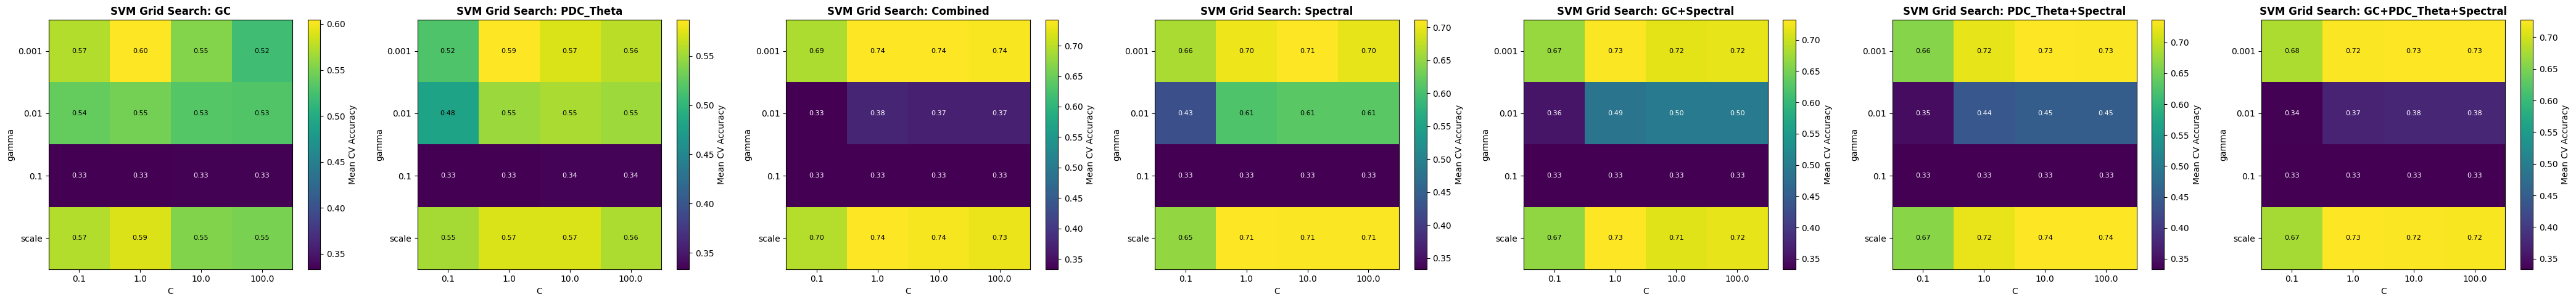

Saved svm_hyperparameter_heatmap.png


In [5]:
datasets_list = list(datasets.keys())
fig, axes = plt.subplots(1, len(datasets_list), figsize=(6*len(datasets_list), 5))
if len(datasets_list) == 1:
    axes = [axes]

for ax, name in zip(axes, datasets_list):
    sub = df_svm_grid[df_svm_grid['Dataset'] == name]
    pivot = sub.pivot(index='param_clf__gamma', columns='param_clf__C', values='mean_test_score')
    im = ax.imshow(pivot.values, cmap='viridis', aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('C')
    ax.set_ylabel('gamma')
    ax.set_title(f'SVM Grid Search: {name}', fontweight='bold')
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        color='white' if val < pivot.values.max() * 0.7 else 'black', fontsize=8)
    fig.colorbar(im, ax=ax, label='Mean CV Accuracy')

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'svm_hyperparameter_heatmap.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved svm_hyperparameter_heatmap.png")


In [6]:
print("="*70)
print("4.6 HYPERPARAMETER TUNING COMPLETE")
print("="*70)
best = df_summary.iloc[0]
print(f"Best: {best['Dataset']} + {best['Model']} -> Acc={best['Mean_Accuracy']:.4f}+/-{best['Std_Accuracy']:.4f}")
print(f"Outputs saved in: {OUTPUT_DIR}")
print(f"Figures saved in: {FIG_DIR}")


4.6 HYPERPARAMETER TUNING COMPLETE
Best: Combined + XGBoost_Tuned -> Acc=0.7452+/-0.0313
Outputs saved in: D:\Skripsi\new_data\phase_4_classification\4.6_hyperparameter_tuning\output
Figures saved in: D:\Skripsi\new_data\phase_4_classification\4.6_hyperparameter_tuning\figures
